In [54]:
from sklearn.datasets import make_regression
import numpy as np 

In [55]:
X, y = make_regression(n_samples=4, n_features=1, n_informative=1, n_targets=1, noise=80, random_state=13)


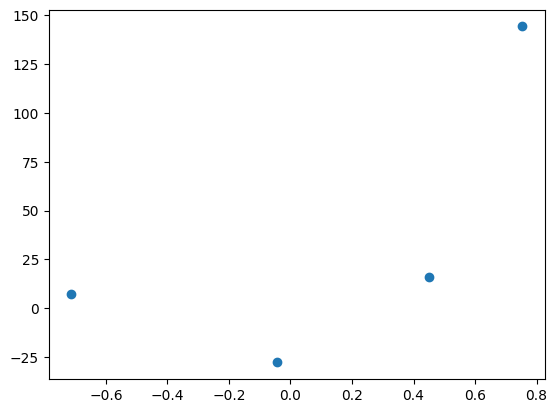

In [56]:
import matplotlib.pyplot as plt
plt.scatter(X,y)

In [57]:
# Lets Apply OLS
from sklearn.linear_model import LinearRegression

In [58]:
lr = LinearRegression()
lr.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [59]:
lr.coef_

array([78.35063668])

In [60]:
lr.intercept_

np.float64(26.15963284313262)

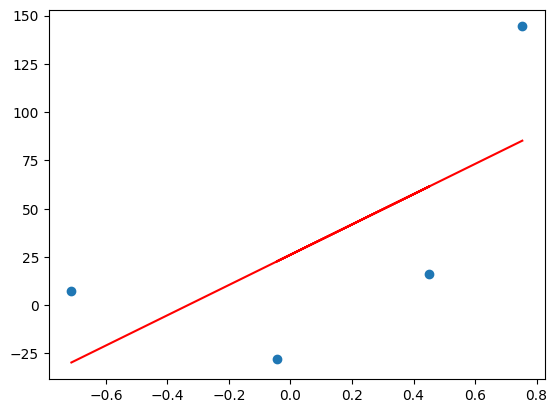

In [61]:
plt.scatter(X,y)
plt.plot(X,lr.predict(X), color='red')

In [62]:
# Lets apply GD assuming slope is constant m = 78.35
# And let's assume the starting value for intercep b = 100

y_pred = ((78.35 * X) + 100).reshape(4)

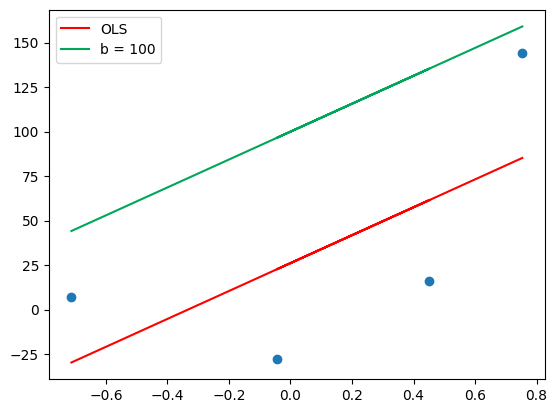

In [63]:
plt.scatter(X,y)
plt.plot(X, lr.predict(X), color='red', label='OLS')
plt.plot(X, y_pred, color='#00a65a', label='b = 100')
plt.legend()
plt.show()


In [64]:
m = 78.35
b = 100

loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(590.7223659179078)

In [65]:
# Lets take Learning Rate = 0.1
LR = 0.1

step_size = loss_slope * LR
step_size

np.float64(59.072236591790784)

In [66]:
# Calculating the new intercept
b = b - step_size
b

np.float64(40.927763408209216)

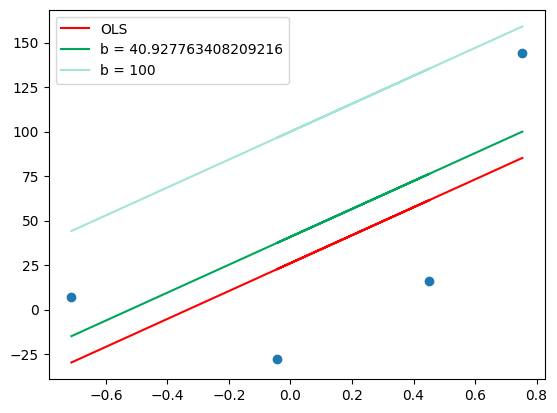

In [67]:
y_pred1 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X, lr.predict(X), color='red', label='OLS')
plt.plot(X, y_pred1, color='#00a65a', label='b = {}'.format(b))
plt.plot(X, y_pred, color='#A3E4D7', label='b = 100')
plt.legend()
plt.show()


In [68]:
# Iteration 2
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(118.14447318358157)

In [69]:
step_size = loss_slope * LR
step_size

np.float64(11.814447318358157)

In [70]:
b = b - step_size
b

np.float64(29.11331608985106)

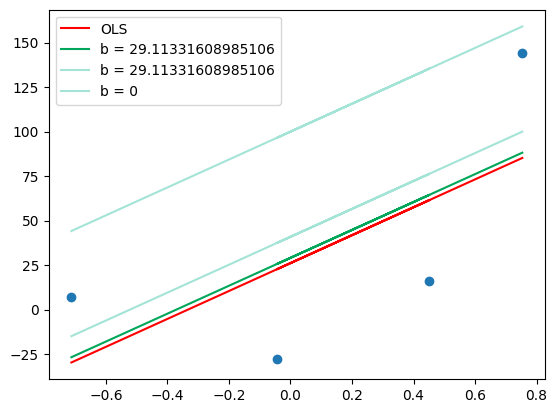

In [71]:
y_pred2 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X, lr.predict(X), color='red', label='OLS')
plt.plot(X, y_pred2, color='#00a65a', label='b = {}'.format(b))
plt.plot(X, y_pred1, color='#A3E4D7', label='b = {}'.format(b))
plt.plot(X, y_pred, color='#A3E4D7', label='b = 0')
plt.legend()
plt.show()


In [72]:
# Iteration 3
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(23.62889463671634)

In [73]:
step_size = loss_slope * LR
step_size

np.float64(2.362889463671634)

In [74]:
b = b - step_size
b

np.float64(26.750426626179426)

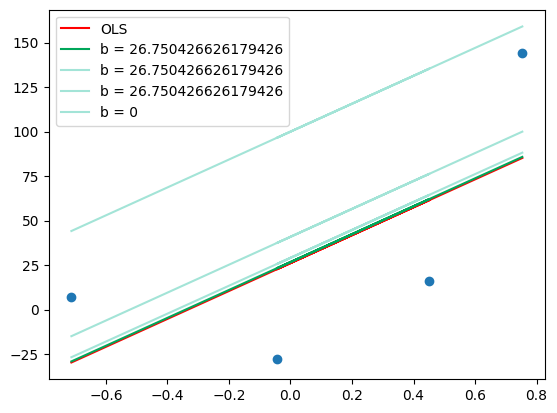

In [75]:
y_pred3 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X, lr.predict(X), color='red', label='OLS')
plt.plot(X, y_pred3, color='#00a65a', label='b = {}'.format(b))
plt.plot(X, y_pred2, color='#A3E4D7', label='b = {}'.format(b))
plt.plot(X, y_pred1, color='#A3E4D7', label='b = {}'.format(b))
plt.plot(X, y_pred, color='#A3E4D7', label='b = 0')
plt.legend()
plt.show()

In [76]:
# When you are far away from the goal you take big steps and as and when are you are coming closer to it you tend to take small steps

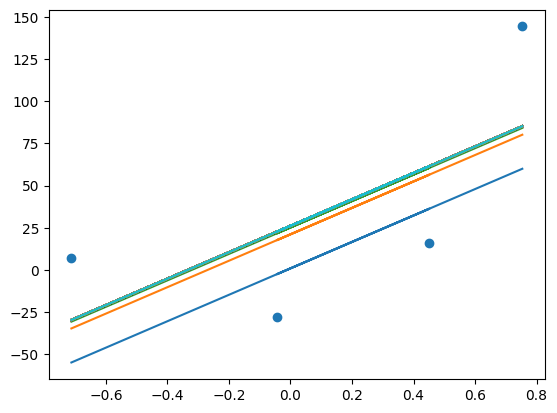

In [77]:
b = -100
m = 78.35
LR = 0.1

epochs = 100

for i in range(epochs):
    loss_slope = -2 * np.sum(y - m*X.ravel() - b)
    b = b - (LR * loss_slope)
    
    y_pred = m * X + b
    
    plt.plot(X,y_pred)
    
plt.scatter(X,y)    